# Quantum Phase estimation

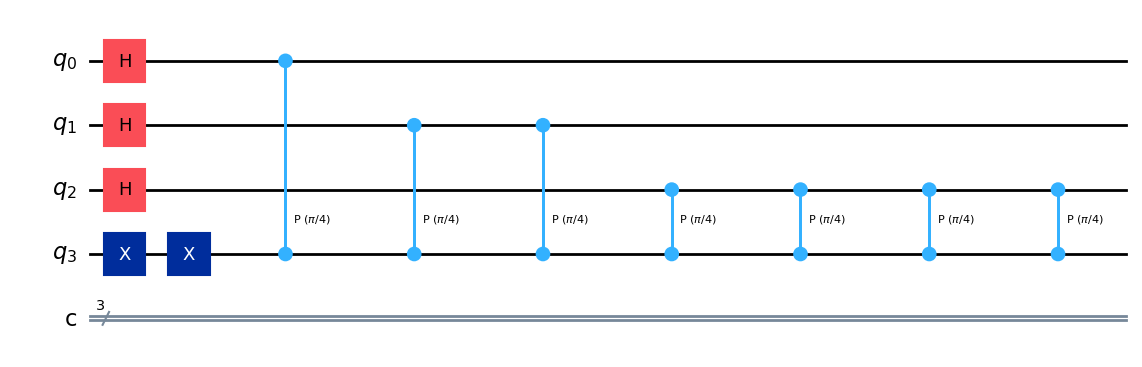

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from math import pi
import numpy as np

# 3 ancilla bits → precision = 1/8
t = 3

# total qubits = t ancillas + 1 target
qc = QuantumCircuit(t + 1, t)

anc = range(t)      # ancillas 0,1,2
target = t          # target qubit index = 3

# --- Step 1: prepare eigenstate |1> ---
qc.x(target)

# --- ALTERNATIVELY Step 1: prepare eigenstate |0> ---
qc.x(target)

# --- Step 2: put ancillas into superposition ---
for q in anc:
    qc.h(q)

# --- Step 3: controlled T^(2^k) operations ---
# T gate adds phase π/4 to |1>
for k in range(t):
    for _ in range(2**k):
        qc.cp(pi/4, anc[k], target)

display(qc.draw('mpl'))

3-bit QPE result for T-gate eigenvalue:
{'000': 10000}


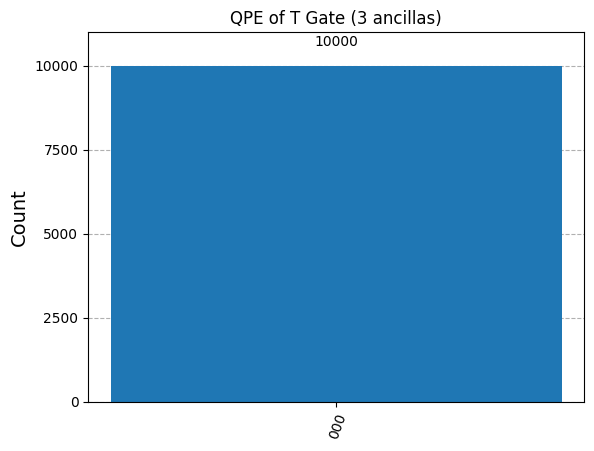

In [8]:
# --- Step 4: inverse QFT ---
iqft = QFT(num_qubits=t, inverse=True, do_swaps=True)
qc.append(iqft.to_gate(label="QFT†"), anc)

# --- Step 5: measure ancillas ---
qc.measure(anc, range(t))

# --- Run with AerSimulator ---
ideal_sim = AerSimulator()

qc_transpiled = transpile(qc, ideal_sim)
result = ideal_sim.run(qc_transpiled, shots=10000).result()
counts = result.get_counts()

print("3-bit QPE result for T-gate eigenvalue:")
print(counts)

plot_histogram(counts, title="QPE of T Gate (3 ancillas)")
# plt.show()


In [9]:
# --- Postprocessing: compute estimated eigenvalue ---
# Find most frequent bitstring
most_common = max(counts, key=counts.get)
print(f"\nMost frequent measured bitstring: {most_common}")

# Qiskit returns bits little-endian → reverse for MSB→LSB
bitstring = most_common[::-1]
print(f"Interpreted as binary fraction (MSB→LSB): {bitstring}")

# Convert binary to decimal phase φ = m / 2^t
m = int(bitstring, 2)
phi_est = m / (2**t)
print(f"Estimated phase φ ≈ {phi_est:.5f}")

# Compute estimated eigenvalue λ = exp(2πi φ)
lambda_est = np.exp(2j * np.pi * phi_est)
print(f"Estimated eigenvalue λ ≈ {lambda_est:.5f}")

# True values
print("\nTrue phase:      1/8 = 0.125")
# print("True eigenvalue: exp(iπ/4) = exp(2πi * 1/8)")


Most frequent measured bitstring: 000
Interpreted as binary fraction (MSB→LSB): 000
Estimated phase φ ≈ 0.00000
Estimated eigenvalue λ ≈ 1.00000+0.00000j

True phase:      1/8 = 0.125
True eigenvalue: exp(iπ/4) = exp(2πi * 1/8)


# Quantum Phase estimation on not eigenstate

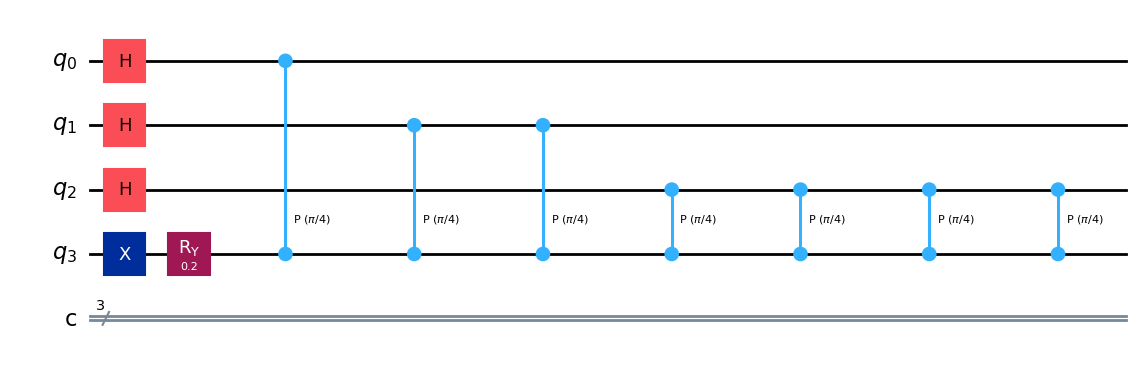

In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from math import pi
import numpy as np

# 3 ancilla bits → precision = 1/8
t = 3

# total qubits = t ancillas + 1 target
qc = QuantumCircuit(t + 1, t)

anc = range(t)      # ancillas 0,1,2
target = t          # target qubit index = 3

# --- Step 1: prepare eigenstate |1> --- AND THEN ROTATE IT a LITTLE BIT
qc.x(target)
qc.ry(0.2, target)

# --- Step 2: put ancillas into superposition ---
for q in anc:
    qc.h(q)

# --- Step 3: controlled T^(2^k) operations ---
# T gate adds phase π/4 to |1>
for k in range(t):
    for _ in range(2**k):
        qc.cp(pi/4, anc[k], target)

display(qc.draw('mpl'))

3-bit QPE result for T-gate eigenvalue:
{'000': 95, '001': 9905}


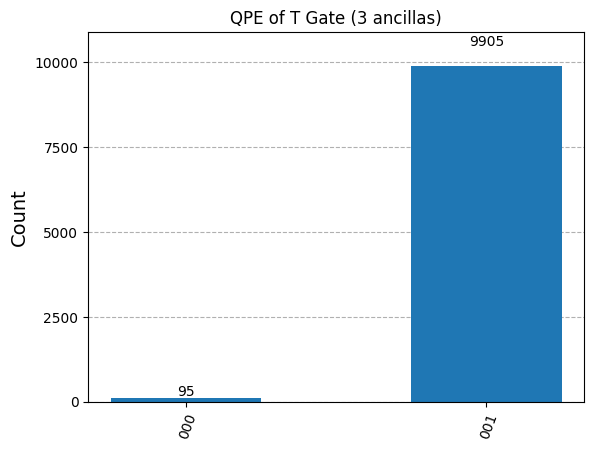

In [15]:
# --- Step 4: inverse QFT ---
iqft = QFT(num_qubits=t, inverse=True, do_swaps=True)
qc.append(iqft.to_gate(label="QFT†"), anc)

# --- Step 5: measure ancillas ---
qc.measure(anc, range(t))

# --- Run with AerSimulator ---
ideal_sim = AerSimulator()

qc_transpiled = transpile(qc, ideal_sim)
result = ideal_sim.run(qc_transpiled, shots=10000).result()
counts = result.get_counts()

print("3-bit QPE result for T-gate eigenvalue:")
print(counts)

plot_histogram(counts, title="QPE of T Gate (3 ancillas)")
# plt.show()

In [16]:
# --- Postprocessing: compute estimated eigenvalue ---
# Find most frequent bitstring
most_common = max(counts, key=counts.get)
print(f"\nMost frequent measured bitstring: {most_common}")

# Qiskit returns bits little-endian → reverse for MSB→LSB
bitstring = most_common[::-1]
print(f"Interpreted as binary fraction (MSB→LSB): {bitstring}")

# Convert binary to decimal phase φ = m / 2^t
m = int(bitstring, 2)
phi_est = m / (2**t)
print(f"Estimated phase φ ≈ {phi_est:.5f}")

# Compute estimated eigenvalue λ = exp(2πi φ)
lambda_est = np.exp(2j * np.pi * phi_est)
print(f"Estimated eigenvalue λ ≈ {lambda_est:.5f}")

# True values
print("\nTrue phase:      1/8 = 0.125")
# print("True eigenvalue: exp(iπ/4) = exp(2πi * 1/8)")


Most frequent measured bitstring: 001
Interpreted as binary fraction (MSB→LSB): 100
Estimated phase φ ≈ 0.50000
Estimated eigenvalue λ ≈ -1.00000+0.00000j

True phase:      1/8 = 0.125
True eigenvalue: exp(iπ/4) = exp(2πi * 1/8)


# The QPE with noisy simulator

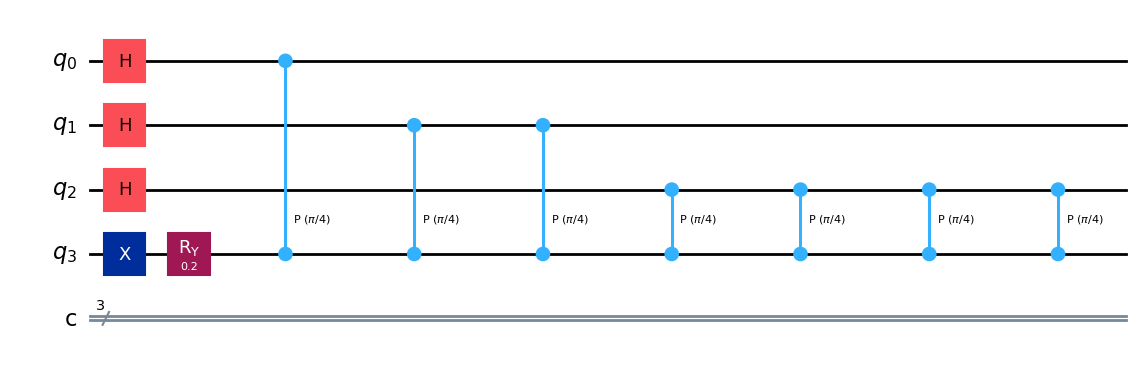

In [20]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from math import pi
import numpy as np

# 3 ancilla bits → precision = 1/8
t = 3

# total qubits = t ancillas + 1 target
qc = QuantumCircuit(t + 1, t)

anc = range(t)      # ancillas 0,1,2
target = t          # target qubit index = 3

# --- Step 1: prepare eigenstate |1> --- AND THEN ROTATE IT a LITTLE BIT
qc.x(target)
qc.ry(0.2, target)

# --- Step 2: put ancillas into superposition ---
for q in anc:
    qc.h(q)

# --- Step 3: controlled T^(2^k) operations ---
# T gate adds phase π/4 to |1>
for k in range(t):
    for _ in range(2**k):
        qc.cp(pi/4, anc[k], target)

display(qc.draw('mpl'))

In [21]:
from qiskit_aer.noise import NoiseModel, depolarizing_error, thermal_relaxation_error
import numpy as np

# Parametry koherence a časů bran
T1 = 80e-6   # 80 microseconds
T2 = 60e-6   # 60 microseconds
t_1q = 35e-9 # 35 ns
t_2q = 250e-9# 250 ns

# Depolarizační pravděpodobnosti
p_1q = 1.0e-3
p_2q = 1.5e-2

# Čtecí chyba ~2% (symetrická)
p_ro = 0.02

noise_model = NoiseModel()

# 1q: termální relaxace + depolarizace (kompozice)
relax_1q = thermal_relaxation_error(T1, T2, t_1q)
depol_1q = depolarizing_error(p_1q, 1)
err_1q = relax_1q.compose(depol_1q)

# 2q (CX): termální relaxace na obou qubitech + depolarizace dvouqubitová
relax_2q = thermal_relaxation_error(T1, T2, t_2q).tensor(thermal_relaxation_error(T1, T2, t_2q))
depol_2q = depolarizing_error(p_2q, 2)
err_2q = relax_2q.compose(depol_2q)

# Přiřadíme šum k branám
oneq_gates = ['id','x','y','z','h','sx','rx','ry','rz']
for g in oneq_gates:
    noise_model.add_all_qubit_quantum_error(err_1q, g)

twoq_gates = ['cx']
for g in twoq_gates:
    noise_model.add_all_qubit_quantum_error(err_2q, g)

# Čtecí chyba pro každý qubit (2x2 matice chyb)
ro_matrix = [[1-p_ro, p_ro], [p_ro, 1-p_ro]]
noise_model.add_all_qubit_readout_error(ro_matrix)

noise_model

<NoiseModel on ['ry', 'x', 'rx', 'sx', 'measure', 'y', 'z', 'h', 'rz', 'cx', 'id']>

3-bit QPE result for T-gate eigenvalue:
{'100': 377, '110': 198, '101': 586, '111': 262, '011': 403, '000': 973, '010': 622, '001': 6579}


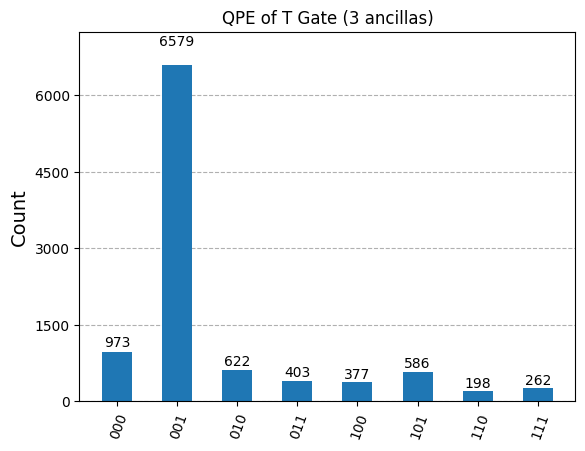

In [22]:
# --- Step 4: inverse QFT ---
iqft = QFT(num_qubits=t, inverse=True, do_swaps=True)
qc.append(iqft.to_gate(label="QFT†"), anc)

# --- Step 5: measure ancillas ---
qc.measure(anc, range(t))

# --- Run with AerSimulator ---
noisy_sim = AerSimulator(noise_model=noise_model)
qc_t_noisy = transpile(qc, noisy_sim)
res_noisy = noisy_sim.run(qc_t_noisy, shots=10000).result()
counts_noisy = res_noisy.get_counts()


print("3-bit QPE result for T-gate eigenvalue:")
print(counts_noisy)

plot_histogram(counts_noisy, title="QPE of T Gate (3 ancillas)")
# plt.show()

# Groover algorithm example

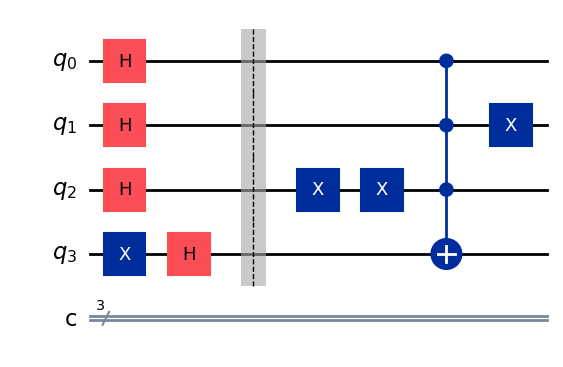

In [23]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.circuit.library.standard_gates import C3XGate

qc = QuantumCircuit(4,3)

qc.h(0)
qc.h(1)
qc.h(2)

qc.x(3)
qc.h(3)

# ------------ Oracle -------------
qc.barrier()

#qc.h(2)
qc.x(2)
qc.x(2)
# qc.ccx(0,1,2)
qc.append(C3XGate(), [0, 1, 2, 3])
qc.x(1)
#qc.h(2)
# --------------------------------

qc.draw(output='mpl')

In [24]:
state = Statevector(qc)
print(state)

Statevector([ 0.25+0.j,  0.25+0.j,  0.25+0.j,  0.25+0.j,  0.25+0.j,
             -0.25+0.j,  0.25+0.j,  0.25+0.j, -0.25+0.j, -0.25+0.j,
             -0.25+0.j, -0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j,
             -0.25+0.j],
            dims=(2, 2, 2, 2))


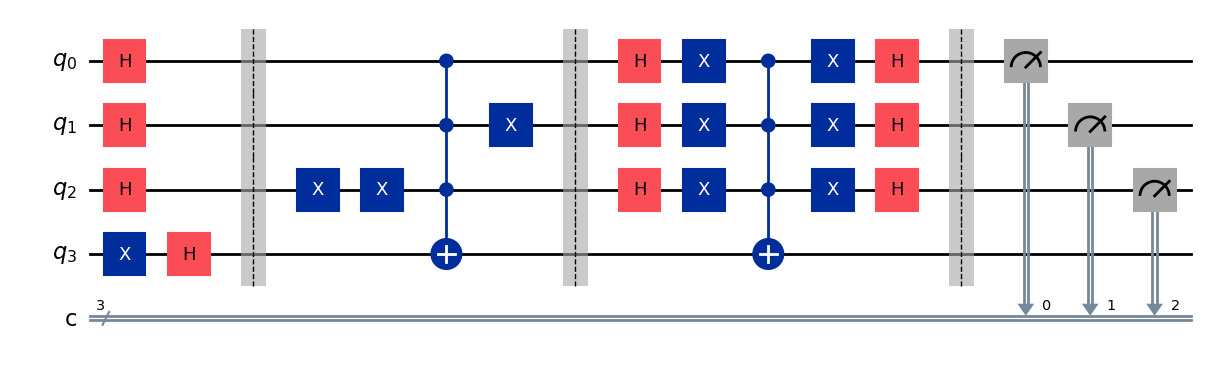

In [25]:
qc.barrier()

qc.h(0)
qc.h(1)
qc.h(2)

qc.x(0)
qc.x(1)
qc.x(2)

qc.append(C3XGate(), [0, 1, 2, 3])

qc.x(0)
qc.x(1)
qc.x(2)

qc.h(0)
qc.h(1)
qc.h(2)

qc.barrier()

qc.measure(0,0)
qc.measure(1,1)
qc.measure(2,2)

qc.draw(output='mpl')

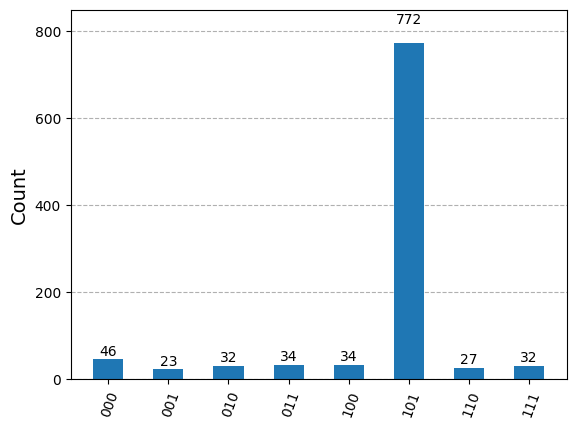

In [22]:
from qiskit_aer import AerSimulator

backend = AerSimulator()
results = backend.run(qc, shots=1000).result()
counts = results.get_counts()
plot_histogram(counts)

# Groover example more general formulation


In [27]:
import qiskit 
print(qiskit.version.get_version_info())


1.2.4


In [39]:
# Built-in modules
import math

# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZGate
from qiskit.visualization import plot_distribution
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.circuit.library import GroverOperator


# # Imports from Qiskit Runtime
# from qiskit_ibm_runtime import QiskitRuntimeService
# from qiskit_ibm_runtime import SamplerV2 as Sampler


def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states
    Compatible with Qiskit 1.2.4 (no MCMTGate)
    """

    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits)

    for target in marked_states:
        # Qiskit endian correction:
        rev_target = target[::-1]

        # Find indices where bit = '0'  (i.e., open controls)
        zero_inds = [i for i, bit in enumerate(rev_target) if bit == "0"]

        # 1. Apply X to zero-controls (|0> becomes |1>)
        if zero_inds:
            qc.x(zero_inds)

        # 2. Apply multi-controlled Z with (num_qubits - 1) controls
        base_gate = ZGate()
        mcz = base_gate.control(num_ctrl_qubits=num_qubits - 1)

        # Controls = all qubits except last
        ctrl_qubits = list(range(num_qubits - 1))
        target_qubit = num_qubits - 1

        qc.append(mcz, ctrl_qubits + [target_qubit])

        # 3. Undo X on zero-controls
        if zero_inds:
            qc.x(zero_inds)

    return qc


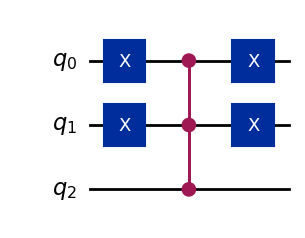

In [36]:
marked_states = ["100"]
 
oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")

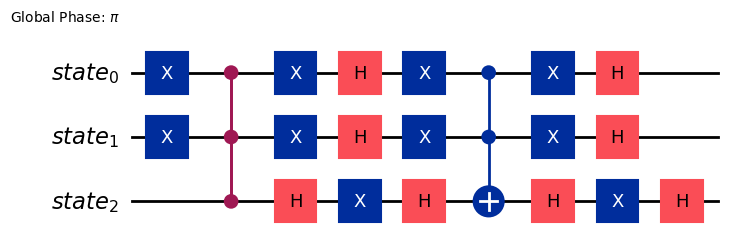

In [41]:
grover_op = GroverOperator(oracle)
grover_op.decompose().draw(output="mpl")

In [43]:
optimal_num_iterations = math.floor(
    math.pi
    / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)
print(f"Optimal number of iterations is: {optimal_num_iterations}")

Optimal number of iterations is: 2


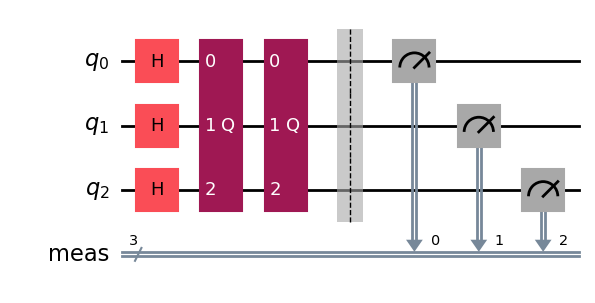

In [44]:
qc = QuantumCircuit(grover_op.num_qubits)
# Create even superposition of all basis states
qc.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
# Measure all qubits
qc.measure_all()
qc.draw(output="mpl", style="iqp")

{'110': 73, '101': 83, '011': 82, '111': 75, '000': 99, '010': 81, '001': 76, '100': 9431}


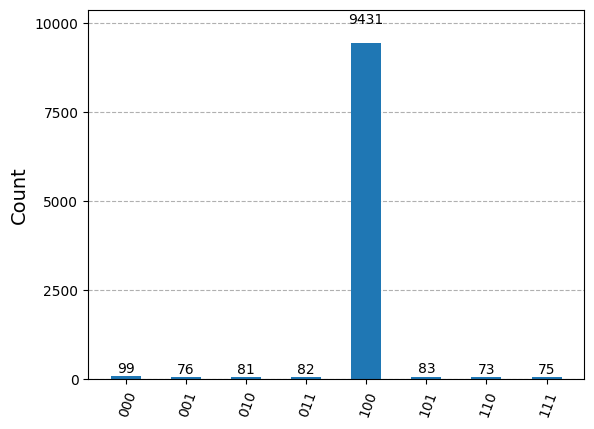

In [47]:
ideal_sim = AerSimulator()

qc_transpiled = transpile(qc, ideal_sim)
result = ideal_sim.run(qc_transpiled, shots=10000).result()
counts = result.get_counts()

# print("3-bit QPE result for T-gate eigenvalue:")
print(counts)

plot_histogram(counts)

## noisy simulator

3-bit QPE result for T-gate eigenvalue:
{'010': 497, '000': 702, '001': 534, '011': 469, '111': 565, '101': 742, '110': 727, '100': 5764}


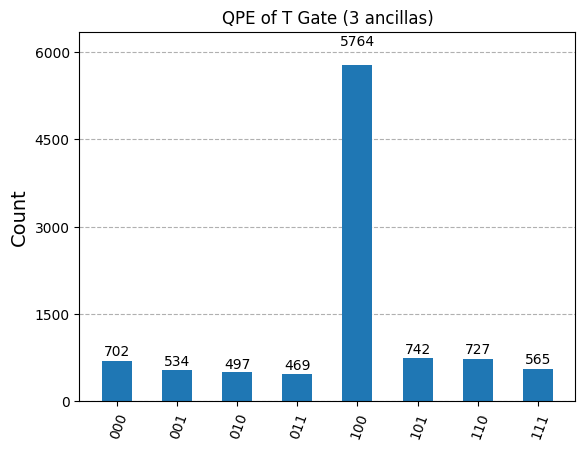

In [48]:
noisy_sim = AerSimulator(noise_model=noise_model)
qc_t_noisy = transpile(qc, noisy_sim)
res_noisy = noisy_sim.run(qc_t_noisy, shots=10000).result()
counts_noisy = res_noisy.get_counts()


print("3-bit QPE result for T-gate eigenvalue:")
print(counts_noisy)

plot_histogram(counts_noisy, title="QPE of T Gate (3 ancillas)")